# Rainfall Data Exploration for Crop Calendar Optimization

This notebook explores the rainfall data from 5 regions to understand patterns for crop calendar optimization.

**Data Sources:**

- Daily rainfall data from CHIRPS and TAMSAT satellite products
- 5 regional datasets spanning 1983-2019


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
RAINFALL_DIR = DATA_RAW / 'RainfallData'

print("Libraries imported successfully!")
print(f"Raw data path: {DATA_RAW}")
print(f"Processed data path: {DATA_PROCESSED}")

Libraries imported successfully!
Raw data path: ../data/raw
Processed data path: ../data/processed


In [ ]:
def load_rainfall_data(data_dir):
    """Load all region CSV files and combine them into a single DataFrame."""
    all_data = []
    region_files = sorted(data_dir.glob('Region*.csv'))
    
    for file in region_files:
        region_name = file.stem  # e.g., 'Region1'
        df = pd.read_csv(file)
        df['Region'] = region_name
        all_data.append(df)
        print(f"Loaded {region_name}: {len(df)} records")
    
    combined_df = pd.concat(all_data, ignore_index=True)
    return combined_df

rainfall_df = load_rainfall_data(RAINFALL_DIR)
print(f"\nTotal records: {len(rainfall_df)}")

Loaded Region1: 13514 records
Loaded Region2: 13514 records
Loaded Region3: 13514 records
Loaded Region4: 13514 records
Loaded Region5: 13514 records

Total records: 67570


In [3]:
rainfall_df['Date'] = pd.to_datetime(rainfall_df[['Year', 'Month', 'Day']])

print("Dataset Info:")
print(f"Date range: {rainfall_df['Date'].min()} to {rainfall_df['Date'].max()}")
print(f"Number of regions: {rainfall_df['Region'].nunique()}")
print(f"Regions: {sorted(rainfall_df['Region'].unique())}")
print(f"\nShape: {rainfall_df.shape}")
print(f"\nColumn types:")
print(rainfall_df.dtypes)

Dataset Info:
Date range: 1983-01-01 00:00:00 to 2019-12-31 00:00:00
Number of regions: 5
Regions: ['Region1', 'Region2', 'Region3', 'Region4', 'Region5']

Shape: (67570, 8)

Column types:
Year               int64
Month              int64
Day                int64
CHIRPS           float64
TAMSAT           float64
Mean             float64
Region            object
Date      datetime64[ns]
dtype: object


In [4]:
rainfall_df.head(10)

,Year,Month,Day,CHIRPS,TAMSAT,Mean,Region,Date
0,1983,1,1,0.000000,0.368836,0.184418,Region1,1983-01-01
1,1983,1,2,0.000000,0.088224,0.044112,Region1,1983-01-02
2,1983,1,3,0.000000,0.108656,0.054328,Region1,1983-01-03
3,1983,1,4,0.811411,1.085505,0.948458,Region1,1983-01-04
4,1983,1,5,1.025914,0.658789,0.842351,Region1,1983-01-05
5,1983,1,6,0.031147,0.558588,0.294867,Region1,1983-01-06
6,1983,1,7,1.796514,0.439710,1.118112,Region1,1983-01-07
7,1983,1,8,0.000000,0.240100,0.120050,Region1,1983-01-08
8,1983,1,9,0.000000,0.557556,0.278778,Region1,1983-01-09
9,1983,1,10,0.000000,0.330813,0.165407,Region1,1983-01-10


## Data Quality Check


In [5]:
print(rainfall_df.isnull().sum())
print(f"\nTotal missing values: {rainfall_df.isnull().sum().sum()}")

print("\nNegative Values Check:")
for col in ['CHIRPS', 'TAMSAT', 'Mean']:
    neg_count = (rainfall_df[col] < 0).sum()
    print(f"  {col}: {neg_count} negative values")

print("\nBasic Statistics by Region:")
rainfall_df.groupby('Region')[['CHIRPS', 'TAMSAT', 'Mean']].describe().round(2)

Year      0
Month     0
Day       0
CHIRPS    0
TAMSAT    0
Mean      0
Region    0
Date      0
dtype: int64

Total missing values: 0

Negative Values Check:
  CHIRPS: 0 negative values
  TAMSAT: 0 negative values
  Mean: 0 negative values

Basic Statistics by Region:


CHIRPS                                             TAMSAT        \
           count  mean   std  min   25%   50%   75%    max    count  mean   
Region                                                                      
Region1  13514.0  3.53  4.30  0.0  0.13  1.87  5.60  36.19  13514.0  3.84   
Region2  13514.0  3.22  3.75  0.0  0.33  1.95  4.84  33.81  13514.0  3.64   
Region3  13514.0  3.64  4.77  0.0  0.00  1.75  5.83  51.22  13514.0  3.99   
Region4  13514.0  3.12  3.75  0.0  0.26  1.80  4.71  51.04  13514.0  3.49   
Region5  13514.0  2.94  3.92  0.0  0.10  1.39  4.40  51.66  13514.0  3.13   

         ...                  Mean                                            
         ...   75%    max    count  mean   std  min   25%   50%   75%    max  
Region   ...                                                                  
Region1  ...  5.89  36.76  13514.0  3.68  4.25  0.0  0.20  2.14  5.87  28.59  
Region2  ...  5.37  41.18  13514.0  3.43  3.82  0.0  0.44  2.20  5.15  27.32  
Region3  ...  6.00  42.03  13514.0  3.82  4.79  0.0  0.00  1.84  6.15  35.53  
Region4  ...  4.94  51.73  13514.0  3.31  3.97  0.0  0.30  1.86  4.93  35.30  
Region5  ...  4.20  52.28  13514.0  3.04  4.03  0.0  0.13  1.45  4.42  37.38  

[5 rows x 24 columns]

In [6]:
print("Overall Rainfall Statistics (mm/day):")
print(rainfall_df[['CHIRPS', 'TAMSAT', 'Mean']].describe().round(3))

print(f"\nCorrelation between CHIRPS and TAMSAT: {rainfall_df['CHIRPS'].corr(rainfall_df['TAMSAT']):.4f}")

Overall Rainfall Statistics (mm/day):
          CHIRPS     TAMSAT       Mean
count  67570.000  67570.000  67570.000
mean       3.291      3.618      3.455
std        4.125      5.232      4.195
min        0.000      0.000      0.000
25%        0.104      0.000      0.190
50%        1.748      1.281      1.879
75%        5.053      5.232      5.271
max       51.656     52.283     37.377

Correlation between CHIRPS and TAMSAT: 0.6027


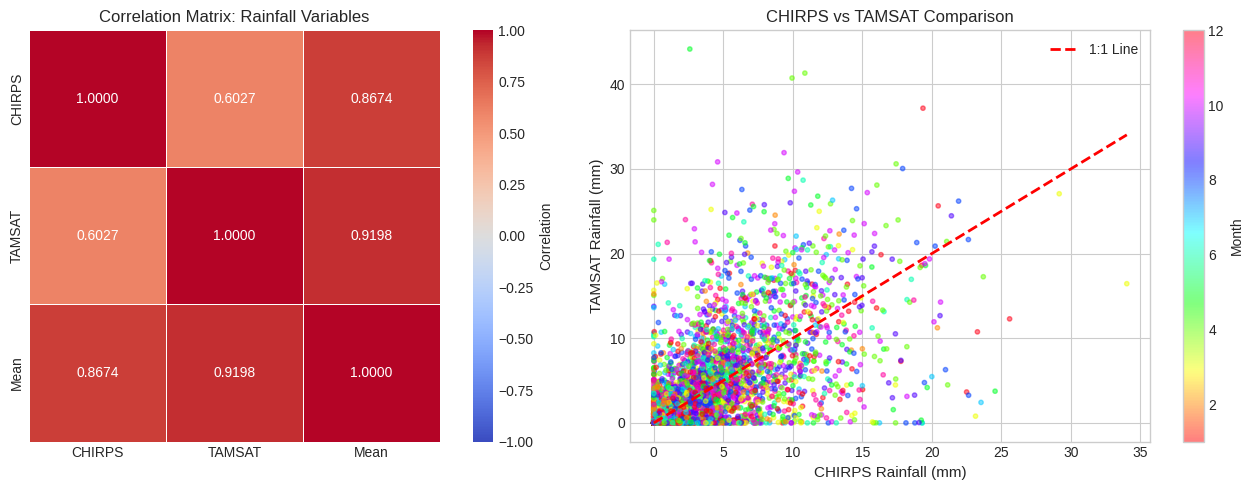


Correlation Summary:
          CHIRPS    TAMSAT      Mean
CHIRPS  1.000000  0.602734  0.867443
TAMSAT  0.602734  1.000000  0.919843
Mean    0.867443  0.919843  1.000000


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

correlation_matrix = rainfall_df[['CHIRPS', 'TAMSAT', 'Mean']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.4f', square=True, linewidths=0.5, ax=axes[0],
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix: Rainfall Variables', fontsize=12)

sample = rainfall_df.sample(min(5000, len(rainfall_df)), random_state=42)  
scatter = axes[1].scatter(sample['CHIRPS'], sample['TAMSAT'], 
                        c=sample['Month'], cmap='hsv', alpha=0.5, s=10)
axes[1].plot([0, sample['CHIRPS'].max()], [0, sample['CHIRPS'].max()], 
            'r--', linewidth=2, label='1:1 Line')
axes[1].set_xlabel('CHIRPS Rainfall (mm)', fontsize=11)
axes[1].set_ylabel('TAMSAT Rainfall (mm)', fontsize=11)
axes[1].set_title('CHIRPS vs TAMSAT Comparison', fontsize=12)
axes[1].legend()
plt.colorbar(scatter, ax=axes[1], label='Month')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCorrelation Summary:")
print(correlation_matrix)

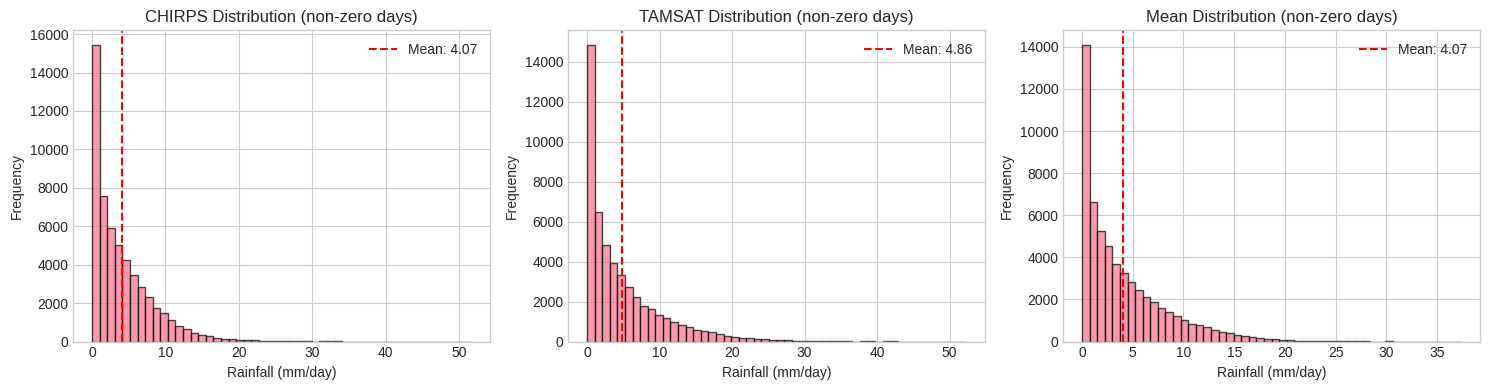

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['CHIRPS', 'TAMSAT', 'Mean']):
    data = rainfall_df[rainfall_df[col] > 0][col]
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Rainfall (mm/day)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col} Distribution (non-zero days)')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'rainfall_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

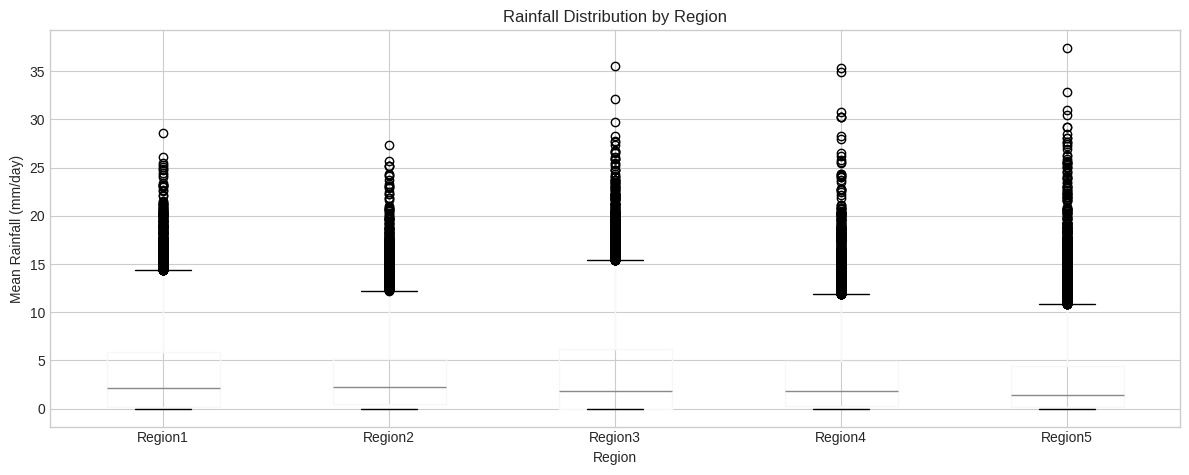

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
rainfall_df.boxplot(column='Mean', by='Region', ax=ax)
ax.set_xlabel('Region')
ax.set_ylabel('Mean Rainfall (mm/day)')
ax.set_title('Rainfall Distribution by Region')
plt.suptitle('')  
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'rainfall_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

## Monthly Rainfall Patterns (Seasonal Analysis)


In [9]:

monthly_stats = rainfall_df.groupby(['Region', 'Month']).agg({
    'Mean': ['mean', 'std', 'sum'],
    'CHIRPS': 'mean',
    'TAMSAT': 'mean'
}).round(3)

monthly_stats.columns = ['Mean_avg', 'Mean_std', 'Mean_total', 'CHIRPS_avg', 'TAMSAT_avg']
monthly_stats = monthly_stats.reset_index()


print("Monthly Average Rainfall (mm/day) by Region:")
pivot_monthly = monthly_stats.pivot(index='Month', columns='Region', values='Mean_avg')
pivot_monthly

Monthly Average Rainfall (mm/day) by Region:


Region,Region1,Region2,Region3,Region4,Region5
Month,,,,,
1,0.407,0.888,1.687,1.392,1.854
2,0.869,1.391,2.198,1.777,2.382
3,2.490,3.359,4.145,3.508,3.728
4,4.910,5.672,5.728,5.330,4.735
5,4.769,4.303,4.031,3.405,2.745
6,4.457,2.707,3.054,1.823,1.205
7,4.618,2.847,3.048,1.568,0.821
8,5.760,4.182,4.742,3.663,2.493
9,4.841,4.406,4.609,4.479,4.000


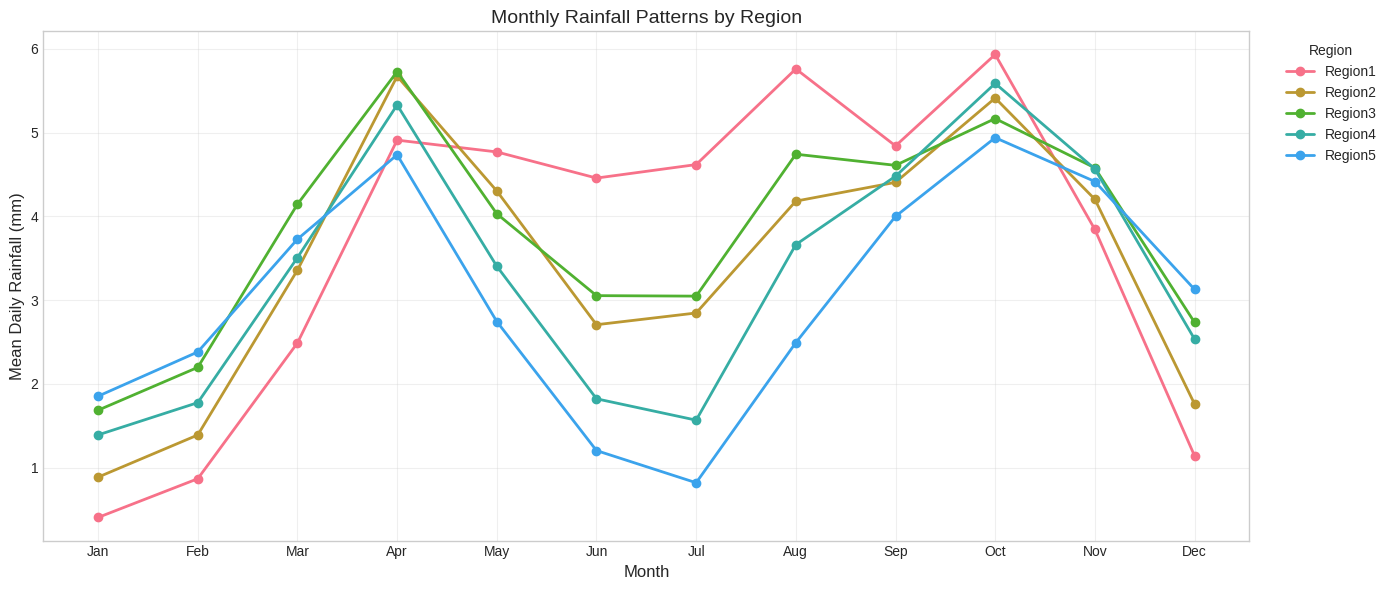

In [10]:

fig, ax = plt.subplots(figsize=(14, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for region in sorted(rainfall_df['Region'].unique()):
    region_data = monthly_stats[monthly_stats['Region'] == region]
    ax.plot(region_data['Month'], region_data['Mean_avg'], 
            marker='o', linewidth=2, markersize=6, label=region)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean Daily Rainfall (mm)', fontsize=12)
ax.set_title('Monthly Rainfall Patterns by Region', fontsize=14)
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'monthly_rainfall_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

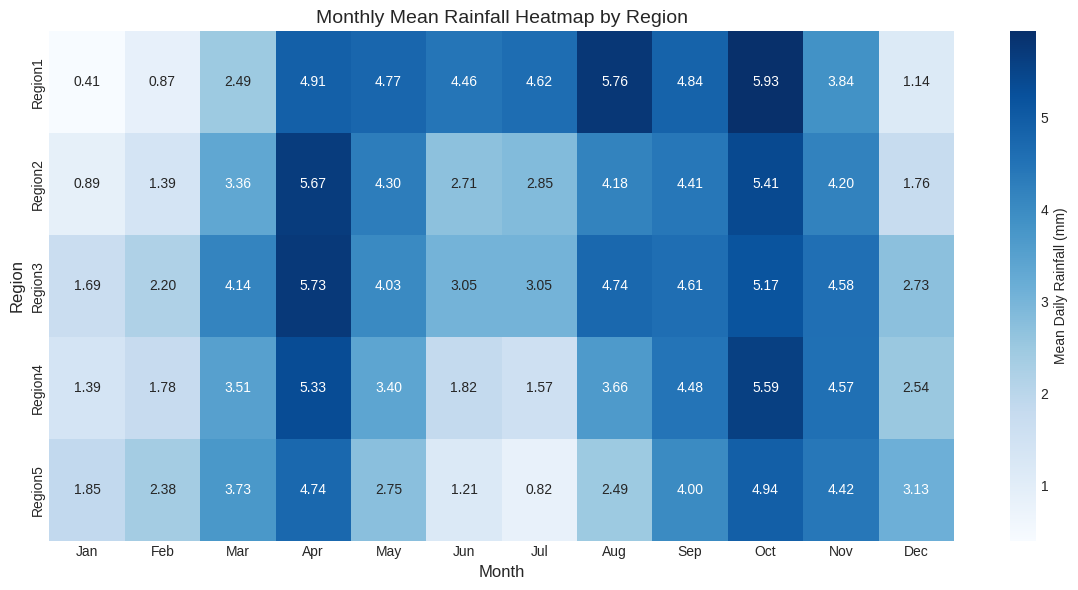

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

heatmap_data = monthly_stats.pivot(index='Region', columns='Month', values='Mean_avg')
heatmap_data.columns = month_names

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues', 
            cbar_kws={'label': 'Mean Daily Rainfall (mm)'}, ax=ax)
ax.set_title('Monthly Mean Rainfall Heatmap by Region', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'rainfall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Annual Rainfall Trends


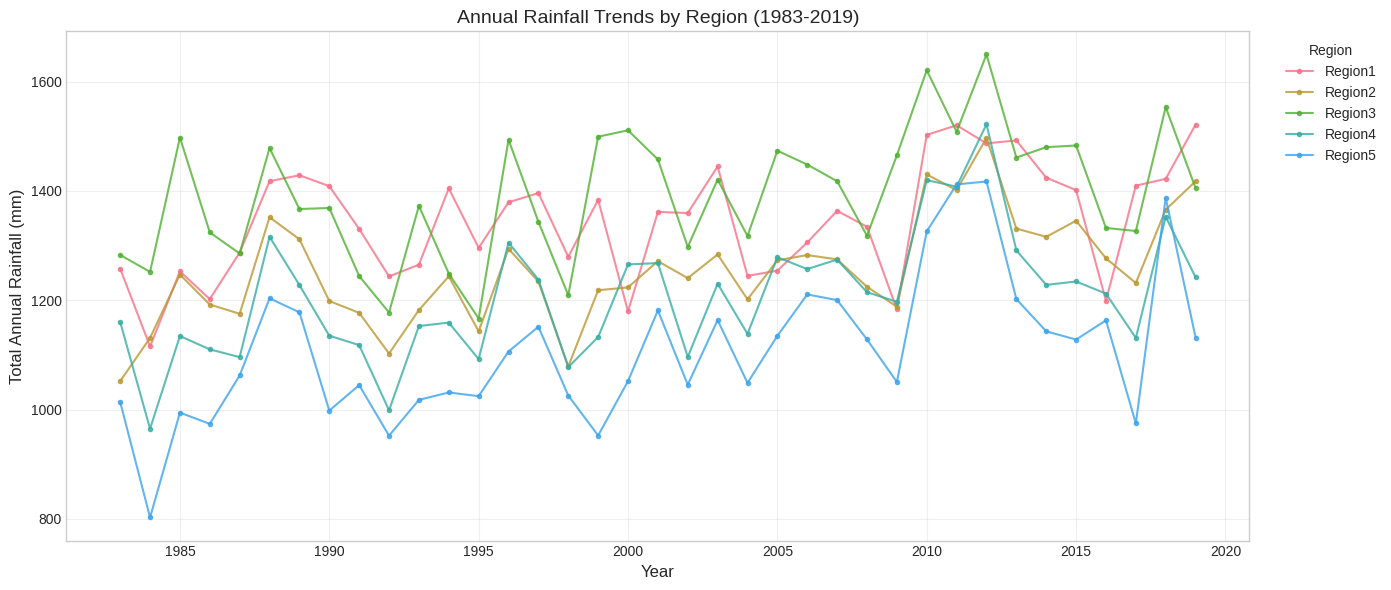

In [12]:
annual_rainfall = rainfall_df.groupby(['Year', 'Region'])['Mean'].sum().reset_index()
annual_rainfall.columns = ['Year', 'Region', 'Annual_Total']

fig, ax = plt.subplots(figsize=(14, 6))

for region in sorted(annual_rainfall['Region'].unique()):
    region_data = annual_rainfall[annual_rainfall['Region'] == region]
    ax.plot(region_data['Year'], region_data['Annual_Total'], 
            marker='.', linewidth=1.5, alpha=0.8, label=region)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Annual Rainfall (mm)', fontsize=12)
ax.set_title('Annual Rainfall Trends by Region (1983-2019)', fontsize=14)
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'annual_rainfall_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Rainy Season Analysis

Identifying rainy seasons is crucial for determining optimal planting windows.


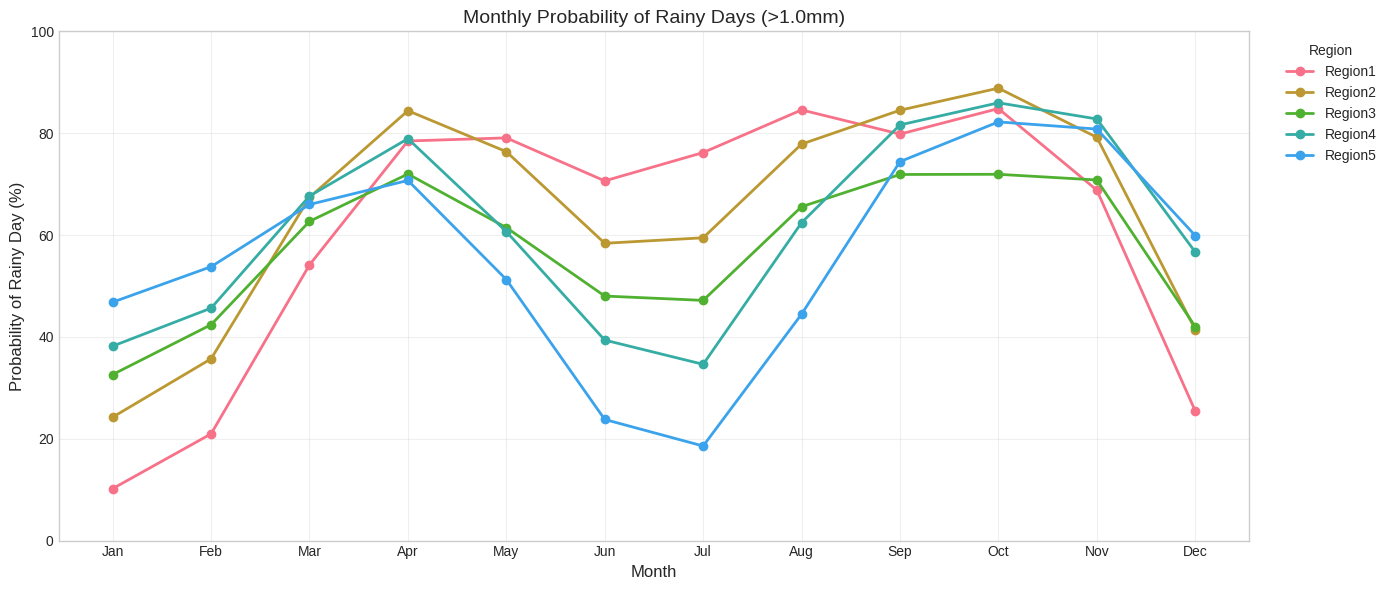

In [13]:
# Calculate rainy days (days with rainfall > 1mm threshold)
RAIN_THRESHOLD = 1.0  # mm

rainfall_df['Rainy_Day'] = rainfall_df['Mean'] > RAIN_THRESHOLD

# Monthly rainy day frequency
rainy_days_monthly = rainfall_df.groupby(['Region', 'Month']).agg({
    'Rainy_Day': 'mean'  # Proportion of rainy days
}).reset_index()
rainy_days_monthly.columns = ['Region', 'Month', 'Rainy_Day_Prob']

# Plot rainy day probability
fig, ax = plt.subplots(figsize=(14, 6))

for region in sorted(rainy_days_monthly['Region'].unique()):
    region_data = rainy_days_monthly[rainy_days_monthly['Region'] == region]
    ax.plot(region_data['Month'], region_data['Rainy_Day_Prob'] * 100, 
            marker='o', linewidth=2, markersize=6, label=region)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Probability of Rainy Day (%)', fontsize=12)
ax.set_title(f'Monthly Probability of Rainy Days (>{RAIN_THRESHOLD}mm)', fontsize=14)
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'rainy_day_probability.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("Peak Rainy Months by Region:")

for region in sorted(rainfall_df['Region'].unique()):
    region_monthly = monthly_stats[monthly_stats['Region'] == region].sort_values('Mean_avg', ascending=False)
    top_months = region_monthly.head(3)['Month'].values
    top_months_names = [month_names[m-1] for m in top_months]
    avg_rainfall = region_monthly.head(3)['Mean_avg'].mean()
    print(f"{region}: {', '.join(top_months_names)} (avg: {avg_rainfall:.2f} mm/day)")

Peak Rainy Months by Region:
Region1: Oct, Aug, Apr (avg: 5.53 mm/day)
Region2: Apr, Oct, Sep (avg: 5.16 mm/day)
Region3: Apr, Oct, Aug (avg: 5.21 mm/day)
Region4: Oct, Apr, Nov (avg: 5.16 mm/day)
Region5: Oct, Apr, Nov (avg: 4.70 mm/day)


In [ ]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

rainfall_df.to_csv(DATA_PROCESSED / 'combined_rainfall_data.csv', index=False)
print(f"Saved: combined_rainfall_data.csv ({len(rainfall_df)} records)")

monthly_stats.to_csv(DATA_PROCESSED / 'monthly_rainfall_stats.csv', index=False)
print(f"Saved: monthly_rainfall_stats.csv ({len(monthly_stats)} records)")

annual_rainfall.to_csv(DATA_PROCESSED / 'annual_rainfall_totals.csv', index=False)
print(f"Saved: annual_rainfall_totals.csv ({len(annual_rainfall)} records)")

rainy_days_monthly.to_csv(DATA_PROCESSED / 'rainy_day_probability.csv', index=False)
print(f"Saved: rainy_day_probability.csv ({len(rainy_days_monthly)} records)")

print("\nAll processed data saved to:", DATA_PROCESSED.resolve())

Saved: combined_rainfall_data.csv (67570 records)
Saved: monthly_rainfall_stats.csv (60 records)
Saved: annual_rainfall_totals.csv (185 records)
Saved: rainy_day_probability.csv (60 records)

All processed data saved to: /home/ayiko/Desktop/crop-calendar-optimization/data/processed
